In [3]:
import os

# Check what's inside data folder
print("Files in data folder:")
print(os.listdir('../data'))

Files in data folder:
['online_retail_II.csv', '.ipynb_checkpoints']


In [4]:
import pandas as pd

print("⏳ Loading data... please wait.")
df = pd.read_csv('../data/online_retail_II.csv', encoding='unicode_escape')

print("✅ File Loaded Successfully!")
print("Shape:", df.shape)
df.head()

⏳ Loading data... please wait.
✅ File Loaded Successfully!
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
# How many rows and columns?
print("Shape:", df.shape)

# What columns do we have?
print("\nColumns:", df.columns.tolist())

# What does the data look like?
df.head(10)

Shape: (1067371, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [6]:
# Get a feel for the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [7]:
# See basic statistics
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [8]:
# Before cleaning
print("Before cleaning:", df.shape)

# Remove rows where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

print("After removing missing Customer IDs:", df.shape)
print("Rows removed:", 1067371 - len(df))

Before cleaning: (1067371, 8)
After removing missing Customer IDs: (824364, 8)
Rows removed: 243007


In [9]:
    # Remove rows where Description is missing
df = df.dropna(subset=['Description'])

print("After removing missing Descriptions:", df.shape)
print("Rows removed:", 824364 - len(df))

After removing missing Descriptions: (824364, 8)
Rows removed: 0


In [10]:
 # Check how many cancelled orders exist
cancelled = df[df['Invoice'].str.startswith('C')]
print("Cancelled orders:", len(cancelled))

# Remove them
df = df[~df['Invoice'].str.startswith('C')]
print("After removing cancellations:", df.shape)
print("Rows removed:", 824364 - len(df))

Cancelled orders: 18744
After removing cancellations: (805620, 8)
Rows removed: 18744


In [11]:
# Check how many negative/zero quantities exist
print("Negative/zero quantities:", len(df[df['Quantity'] <= 0]))
print("Negative/zero prices:", len(df[df['Price'] <= 0]))

# Remove them
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

print("\nAfter removing bad quantities and prices:", df.shape)
print("Rows removed:", 805620 - len(df))

Negative/zero quantities: 0
Negative/zero prices: 71

After removing bad quantities and prices: (805549, 8)
Rows removed: 71


In [12]:
# Convert InvoiceDate from string to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Verify it worked
print("Date column type:", df['InvoiceDate'].dtype)
print("\nEarliest date:", df['InvoiceDate'].min())
print("Latest date:", df['InvoiceDate'].max())
print("Date range (days):", (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days)

Date column type: datetime64[us]

Earliest date: 2009-12-01 07:45:00
Latest date: 2011-12-09 12:50:00
Date range (days): 738


In [13]:
# Convert Customer ID from float to integer to string
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

# Verify
print("Customer ID type:", df['Customer ID'].dtype)
print("\nSample Customer IDs:", df['Customer ID'].head().tolist())
print("\nTotal unique customers:", df['Customer ID'].nunique())

Customer ID type: str

Sample Customer IDs: ['13085', '13085', '13085', '13085', '13085']

Total unique customers: 5878


In [14]:
# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Verify
print("Sample revenue values:")
print(df[['Invoice', 'Quantity', 'Price', 'Revenue']].head(10))

print("\nTotal revenue in dataset: £", round(df['Revenue'].sum(), 2))
print("Average order revenue: £", round(df['Revenue'].mean(), 2))

Sample revenue values:
  Invoice  Quantity  Price  Revenue
0  489434        12   6.95     83.4
1  489434        12   6.75     81.0
2  489434        12   6.75     81.0
3  489434        48   2.10    100.8
4  489434        24   1.25     30.0
5  489434        24   1.65     39.6
6  489434        24   1.25     30.0
7  489434        10   5.95     59.5
8  489435        12   2.55     30.6
9  489435        12   3.75     45.0

Total revenue in dataset: £ 17743429.18
Average order revenue: £ 22.03


In [15]:
# Final overview of clean data
print("=" * 40)
print("FINAL CLEAN DATA SUMMARY")
print("=" * 40)
print(f"Total transactions:    {len(df):,}")
print(f"Unique customers:      {df['Customer ID'].nunique():,}")
print(f"Unique products:       {df['StockCode'].nunique():,}")
print(f"Unique countries:      {df['Country'].nunique():,}")
print(f"Date range:            {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Total revenue:         £{df['Revenue'].sum():,.2f}")
print(f"Avg order value:       £{df['Revenue'].mean():,.2f}")
print("=" * 40)

# Any remaining nulls?
print("\nRemaining nulls:")
print(df.isnull().sum())

FINAL CLEAN DATA SUMMARY
Total transactions:    805,549
Unique customers:      5,878
Unique products:       4,631
Unique countries:      41
Date range:            2009-12-01 → 2011-12-09
Total revenue:         £17,743,429.18
Avg order value:       £22.03

Remaining nulls:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


In [16]:
# Define snapshot date as one day after last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


In [17]:
# Calculate RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

# Verify
print("RFM Table Sample:")
print(rfm.head(10))

print("\nRFM Table Statistics:")
print(rfm.describe())

RFM Table Sample:
             Recency  Frequency  Monetary
Customer ID                              
12346            326         12  77556.46
12347              2          8   5633.32
12348             75          5   2019.40
12349             19          4   4428.69
12350            310          1    334.40
12351            375          1    300.93
12352             36         10   2849.84
12353            204          2    406.76
12354            232          1   1079.40
12355            214          2    947.61

RFM Table Statistics:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    3018.616737
std     209.338707    13.009406   14737.731040
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     348.762500
50%      96.000000     3.000000     898.915000
75%     380.000000     7.000000    2307.090000
max     739.000000   398.000000  608821.650000


In [18]:
# Check 99th percentile values
print("99th percentile values:")
print(f"Recency:   {rfm['Recency'].quantile(0.99):.0f} days")
print(f"Frequency: {rfm['Frequency'].quantile(0.99):.0f} orders")
print(f"Monetary:  £{rfm['Monetary'].quantile(0.99):,.2f}")

print("\n1st percentile values:")
print(f"Monetary:  £{rfm['Monetary'].quantile(0.01):,.2f}")

99th percentile values:
Recency:   726 days
Frequency: 46 orders
Monetary:  £29,730.42

1st percentile values:
Monetary:  £46.85


In [19]:
# Define caps
recency_cap = rfm['Recency'].quantile(0.99)
frequency_cap = rfm['Frequency'].quantile(0.99)
monetary_cap = rfm['Monetary'].quantile(0.99)
monetary_floor = rfm['Monetary'].quantile(0.01)

# Apply caps
rfm['Recency'] = rfm['Recency'].clip(upper=recency_cap)
rfm['Frequency'] = rfm['Frequency'].clip(upper=frequency_cap)
rfm['Monetary'] = rfm['Monetary'].clip(upper=monetary_cap, lower=monetary_floor)

# Verify
print("After Winsorization:")
print(rfm.describe())

After Winsorization:
           Recency    Frequency      Monetary
count  5878.000000  5878.000000   5878.000000
mean    201.257741     5.785471   2353.102019
std     209.151082     7.630332   4338.144850
min       1.000000     1.000000     46.846500
25%      26.000000     1.000000    348.762500
50%      96.000000     3.000000    898.915000
75%     380.000000     7.000000   2307.090000
max     726.000000    46.000000  29730.420200


In [20]:
# Define churn: No purchase in last 90 days
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

# Check the distribution
print("Churn Distribution:")
print(rfm['Churn'].value_counts())
print("\nPercentage of Churn:")
print(rfm['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
1    2989
0    2889
Name: count, dtype: int64

Percentage of Churn:
Churn
1    50.850629
0    49.149371
Name: proportion, dtype: float64


In [21]:
# 1. Average Order Value (AOV)
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# 2. Customer Age (Tenure)
# We need to go back to the original df to find the FIRST purchase date
first_purchase = df.groupby('Customer ID')['InvoiceDate'].min()
rfm['Tenure'] = (snapshot_date - first_purchase).dt.days

# Clip Tenure to 99th percentile as well (for consistency)
rfm['Tenure'] = rfm['Tenure'].clip(upper=rfm['Tenure'].quantile(0.99))

# Check the new features
print(rfm[['AOV', 'Tenure']].describe())

                AOV       Tenure
count   5878.000000  5878.000000
mean     372.342691   474.704661
std      504.317381   223.090093
min       11.161333     1.000000
25%      181.959176   313.000000
50%      285.458750   530.000000
75%      421.498167   668.000000
max    14865.210100   738.000000


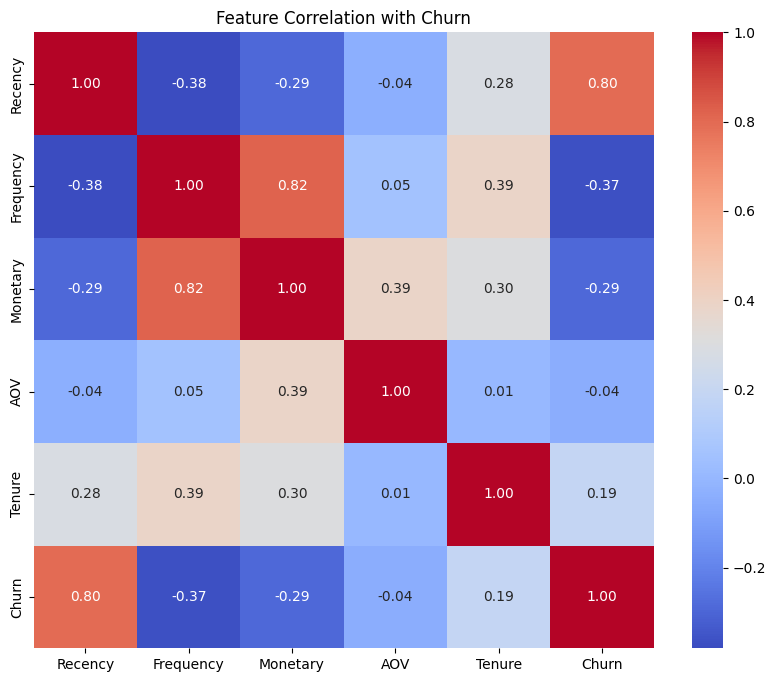

Correlation with Churn:
Churn        1.000000
Recency      0.796555
Tenure       0.187119
AOV         -0.041647
Monetary    -0.292682
Frequency   -0.369297
Name: Churn, dtype: float64


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = rfm[['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Churn']].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Churn")
plt.show()

# Focus specifically on Churn correlation
print("Correlation with Churn:")
print(corr['Churn'].sort_values(ascending=False))

In [23]:
# Let's see our final RFM table
print("Final Feature Set:")
print(rfm.head())
print("\nShape:", rfm.shape)
print("\nAny nulls?")
print(rfm.isnull().sum())

Final Feature Set:
             Recency  Frequency    Monetary  Churn          AOV  Tenure
Customer ID                                                            
12346            326         12  29730.4202      1  2477.535017     726
12347              2          8   5633.3200      0   704.165000     404
12348             75          5   2019.4000      0   403.880000     438
12349             19          4   4428.6900      0  1107.172500     589
12350            310          1    334.4000      1   334.400000     310

Shape: (5878, 6)

Any nulls?
Recency      0
Frequency    0
Monetary     0
Churn        0
AOV          0
Tenure       0
dtype: int64


In [24]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Define Features (X) and Target (y)
# We EXCLUDE Recency because we used it to define Churn (that's cheating!)
features = ['Frequency', 'Monetary', 'AOV', 'Tenure']
X = rfm[features]
y = rfm['Churn']

# 2. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size:  {X_test.shape[0]} customers")

Training set size: 4702 customers
Testing set size:  1176 customers


In [25]:
# 3. Initialize the XGBoost Classifier
# We'll use some standard parameters to start
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate
print("="*30)
print("MODEL PERFORMANCE REPORT")
print("="*30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE REPORT
Accuracy Score: 81.89%

Detailed Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       578
           1       0.83      0.82      0.82       598

    accuracy                           0.82      1176
   macro avg       0.82      0.82      0.82      1176
weighted avg       0.82      0.82      0.82      1176



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [19:55:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


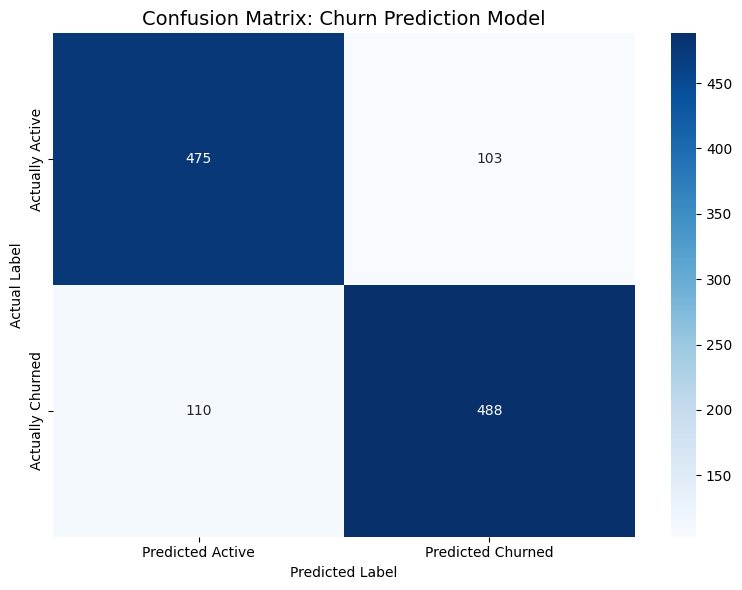

CONFUSION MATRIX BREAKDOWN
True Negatives  (Active → Predicted Active):   475
False Positives (Active → Predicted Churned):  103
False Negatives (Churned → Predicted Active):  110
True Positives  (Churned → Predicted Churned): 488
Correctly identified churners: 488/598


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Build confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Predicted Active', 'Predicted Churned'],
            yticklabels=['Actually Active', 'Actually Churned'])

plt.title('Confusion Matrix: Churn Prediction Model', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print the numbers clearly
print("="*40)
print("CONFUSION MATRIX BREAKDOWN")
print("="*40)
print(f"True Negatives  (Active → Predicted Active):   {cm[0][0]}")
print(f"False Positives (Active → Predicted Churned):  {cm[0][1]}")
print(f"False Negatives (Churned → Predicted Active):  {cm[1][0]}")
print(f"True Positives  (Churned → Predicted Churned): {cm[1][1]}")
print("="*40)
print(f"Correctly identified churners: {cm[1][1]}/{cm[1][0]+cm[1][1]}")

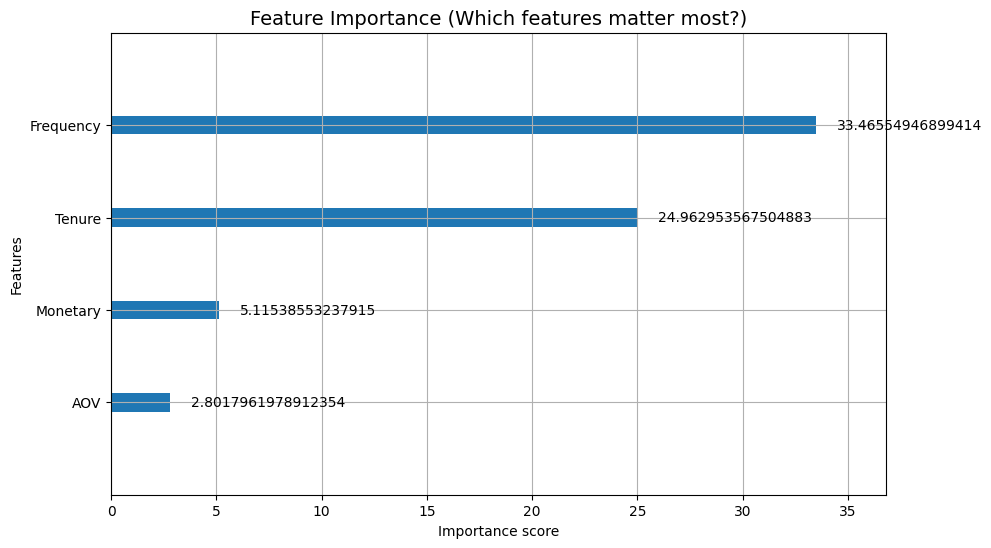

In [27]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain', ax=plt.gca())
plt.title('Feature Importance (Which features matter most?)', fontsize=14)
plt.show()

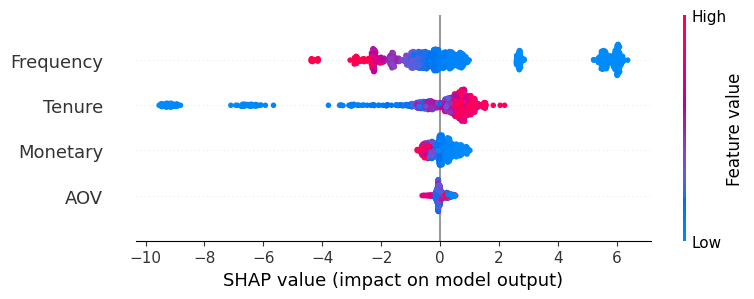

In [28]:
import shap

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

In [29]:
# Add predictions back to the RFM table
rfm['Churn_Probability'] = model.predict_proba(rfm[features])[:, 1]
rfm['Churn_Predicted'] = model.predict(rfm[features])
rfm['Risk_Level'] = pd.cut(
    rfm['Churn_Probability'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk']
)

# Sort by highest churn probability first
churn_list = rfm.sort_values('Churn_Probability', ascending=False)

# Show top 10 highest risk customers
print("TOP 10 HIGHEST RISK CUSTOMERS:")
print("="*60)
print(churn_list[['Recency', 'Frequency', 'Monetary', 
                   'Tenure', 'Churn_Probability', 
                   'Risk_Level']].head(10))

# Summary by risk level
print("\nRISK LEVEL SUMMARY:")
print("="*60)
print(rfm['Risk_Level'].value_counts())

TOP 10 HIGHEST RISK CUSTOMERS:
             Recency  Frequency  Monetary  Tenure  Churn_Probability  \
Customer ID                                                            
18115            698          1   46.8465     698           0.999503   
13438            547          1   46.8465     547           0.999478   
18103            549          1  105.8000     549           0.999471   
15324            701          1  140.2200     701           0.999464   
17902            547          1  216.4000     547           0.999464   
15233            401          1   59.4000     401           0.999451   
13906            409          1   46.8465     409           0.999451   
13303            400          1   61.7200     400           0.999451   
16058            406          1   62.7000     406           0.999451   
16786            394          1   51.8400     394           0.999451   

              Risk_Level  
Customer ID               
18115        🔴 High Risk  
13438        🔴 High Ris

In [30]:
# Create final export dataframe
export_df = churn_list[['Recency', 'Frequency', 
                         'Monetary', 'Tenure',
                         'AOV', 'Churn_Probability', 
                         'Risk_Level']].copy()

# Add action column
export_df['Recommended_Action'] = export_df['Risk_Level'].map({
    '🔴 High Risk': 'Send aggressive retention offer immediately',
    '🟡 Medium Risk': 'Send soft nudge email this week',
    '🟢 Low Risk': 'No action needed - consider upsell'
})

# Export to Excel
export_df.to_excel('churn_risk_report.xlsx', index=True)

print("✅ Churn Risk Report exported successfully!")
print(f"File saved as: churn_risk_report.xlsx")
print(f"\nReport contains {len(export_df)} customers")
print(f"High Risk:   {len(export_df[export_df['Risk_Level'] == '🔴 High Risk'])}")
print(f"Medium Risk: {len(export_df[export_df['Risk_Level'] == '🟡 Medium Risk'])}")
print(f"Low Risk:    {len(export_df[export_df['Risk_Level'] == '🟢 Low Risk'])}")

✅ Churn Risk Report exported successfully!
File saved as: churn_risk_report.xlsx

Report contains 5878 customers
High Risk:   2267
Medium Risk: 1313
Low Risk:    2298


In [31]:
import pickle
import os

# Create models folder
os.makedirs('../models', exist_ok=True)

# Save the model
with open('../models/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the feature list (important!)
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("✅ Model saved successfully!")
print("✅ Features saved successfully!")
print("\nSaved files:")
print(os.listdir('../models'))

✅ Model saved successfully!
✅ Features saved successfully!

Saved files:
['features.pkl', 'churn_model.pkl']


In [32]:
import pickle

# Load saved model
with open('../models/churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('../models/features.pkl', 'rb') as f:
    loaded_features = pickle.load(f)

print("Loaded features:", loaded_features)

# Test prediction on first 5 customers
sample_data = rfm[loaded_features].head(5)

sample_probs = loaded_model.predict_proba(sample_data)[:, 1]
sample_preds = loaded_model.predict(sample_data)

print("\nSample probabilities:", sample_probs)
print("Sample predictions:", sample_preds)

Loaded features: ['Frequency', 'Monetary', 'AOV', 'Tenure']

Sample probabilities: [0.1563642  0.08567508 0.26557636 0.55310434 0.9984725 ]
Sample predictions: [0 0 0 1 1]


In [1]:
import sys
sys.path.append('/Users/hindavi/Churn_Project')

from src.data_loader import load_and_clean
from src.rfm_builder import build_rfm

# Load and clean
df = load_and_clean()

# Build RFM
rfm = build_rfm(df)

print("\nSample RFM:")
print(rfm.head())

⏳ Loading data from: /Users/hindavi/Churn_Project/data/online_retail_II.csv
✅ Loaded 1,067,371 rows and 8 columns

⏳ Starting data cleaning...
   After removing missing Customer IDs: 824,364 rows
   After removing missing Descriptions: 824,364 rows
   After removing cancellations:        805,620 rows
   After removing bad quantities:       805,620 rows
   After removing bad prices:           805,549 rows
   Dates converted to datetime ✅
   Customer ID converted to string ✅
   Revenue column created ✅

✅ Cleaning complete!
   Started with: 1,067,371 rows
   Removed:      261,822 rows
   Final:        805,549 rows
   Unique customers: 5,878

BUILDING RFM TABLE
📅 Snapshot date: 2011-12-10
⏳ Calculating RFM metrics...
✅ RFM calculated for 5,878 customers
⏳ Adding extra features...
✅ Extra features added: AOV, Tenure
⏳ Handling outliers...
✅ Outliers capped at 99th percentile
⏳ Defining churn (threshold: 90 days)...
✅ Churn defined
   Active customers:  2,889
   Churned customers: 2,989
   

In [2]:
from src.model_trainer import run_training_pipeline

# Train model using our RFM table
model, accuracy = run_training_pipeline(rfm)


TRAINING PIPELINE
⏳ Preparing data for training...
✅ Data prepared
   Training set: 4,702 customers
   Testing set:  1,176 customers
   Features:     ['Frequency', 'Monetary', 'AOV', 'Tenure']

⏳ Training XGBoost model...
✅ Model trained successfully!

MODEL PERFORMANCE REPORT
Accuracy Score: 81.80%

Detailed Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       578
           1       0.83      0.81      0.82       598

    accuracy                           0.82      1176
   macro avg       0.82      0.82      0.82      1176
weighted avg       0.82      0.82      0.82      1176

Confusion Matrix:
   True Negatives  (Active → Active):   475
   False Positives (Active → Churned):  103
   False Negatives (Churned → Active):  111
   True Positives  (Churned → Churned): 487

   Correctly caught churners: 487/598

⏳ Saving model...
✅ Model saved to:    /Users/hindavi/Churn_Project/models/churn_model.pkl
✅ Features saved to: /Users/

In [1]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.14/bin/python3.14
